In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [5]:
data = np.load("metrics.npz")

# Извлекаем переменные
count = data["count"]
energy = data["energy"]
zrelye = data["zrelye"]
alive = data["alive"]
newborn  = data["newborn"]
death = data["death"]

df = pd.DataFrame({
    "Такт": count,
    "Живые": alive,
    "Энергия": energy,
    "Зрелые": zrelye,
    "Рожденные":newborn,
    "Умершие":death
})

df.head()

,Такт,Живые,Энергия,Зрелые,Рожденные,Умершие
0,0,15453,46359,0,0,0
1,1,15453,92718,0,0,0
2,2,25655,92497,15422,15453,0
3,3,29780,86688,15358,15416,123
4,4,26863,53198,12798,12864,9607


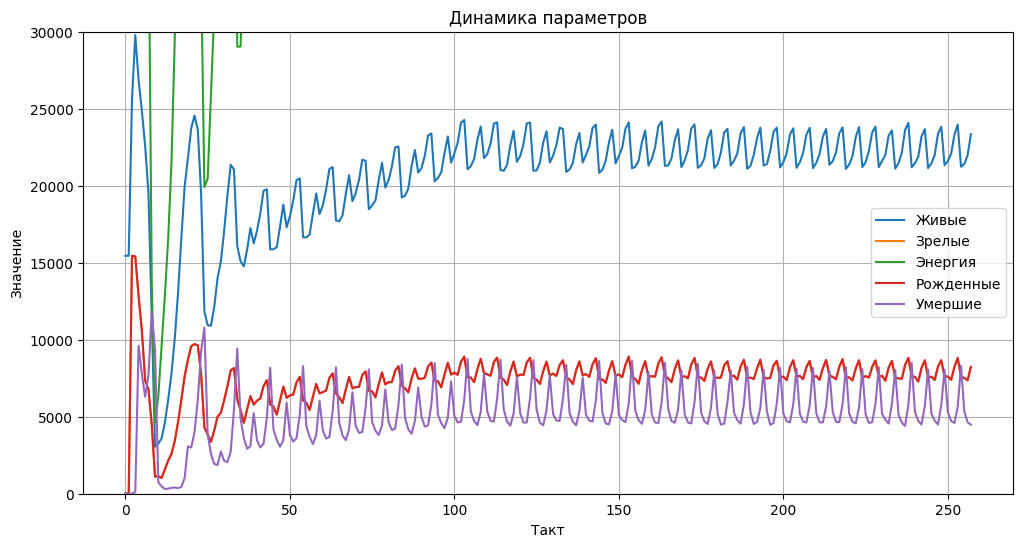

In [6]:
plt.figure(figsize=(12, 6))
for col in ["Живые", "Зрелые", "Энергия", "Рожденные", "Умершие"]:
    plt.plot(df["Такт"], df[col], label=col)
plt.legend()
plt.xlabel("Такт")
plt.ylabel("Значение")
plt.grid(True)
plt.title("Динамика параметров")
plt.ylim(0,3e4)
# plt.xlim(100,110)
plt.show()

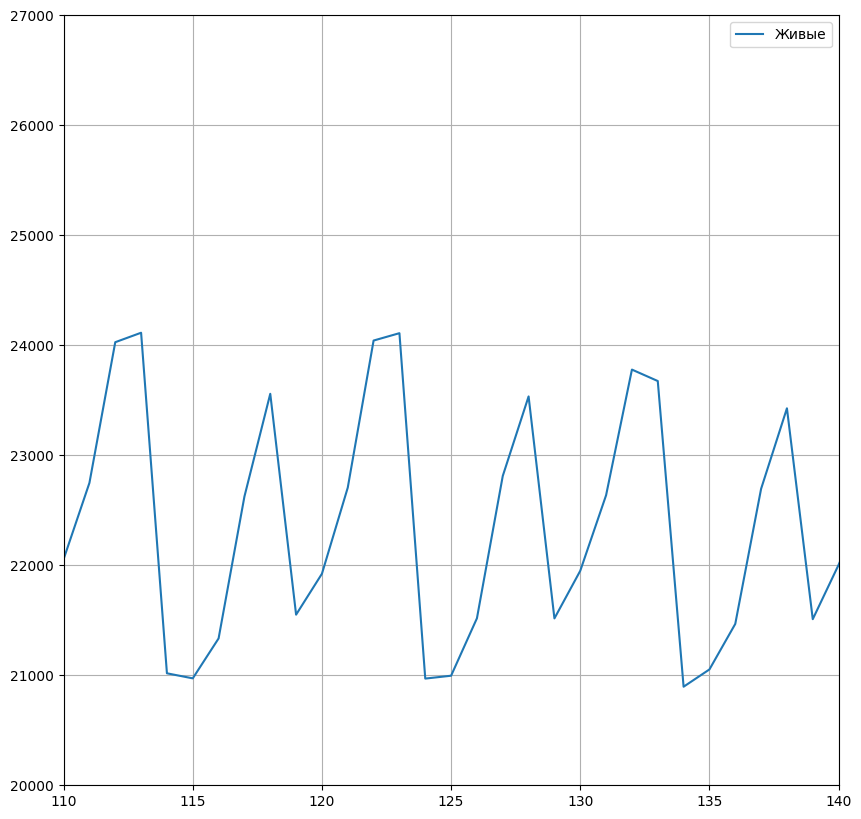

In [12]:
plt.figure(figsize=(10, 10))
col = "Живые"
plt.grid()
plt.xlim(110,140)
plt.ylim(2e4,2.7e4)
plt.plot(df["Такт"], df[col], label=col)
# plt.xlim(40,60)
# col = "Зрелые"
# plt.plot(df["Такт"], df[col], label=col)
col = "Умершие"
# plt.plot(df["Такт"], df[col], label=col)
plt.legend()

# T = 3 - период взросления
# L = 15 - продолжительность жизни

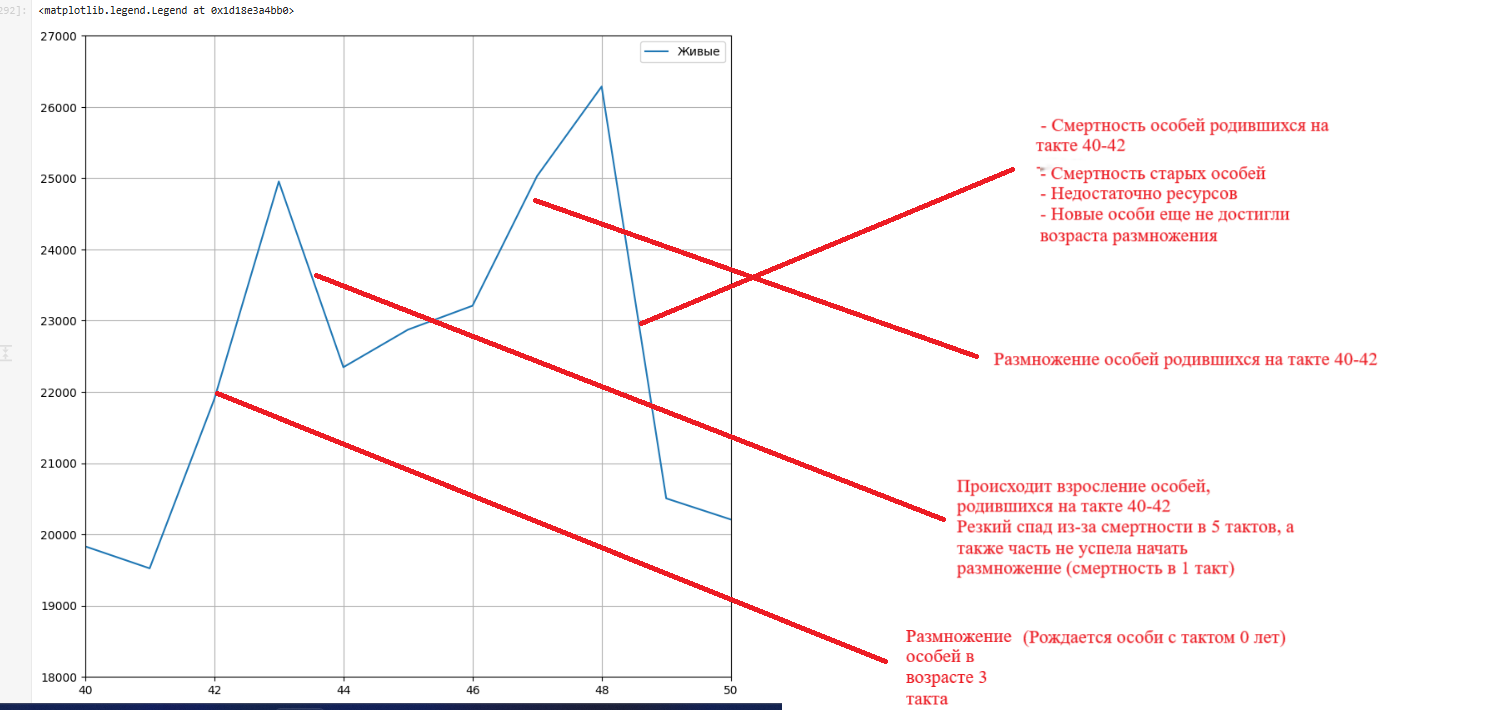

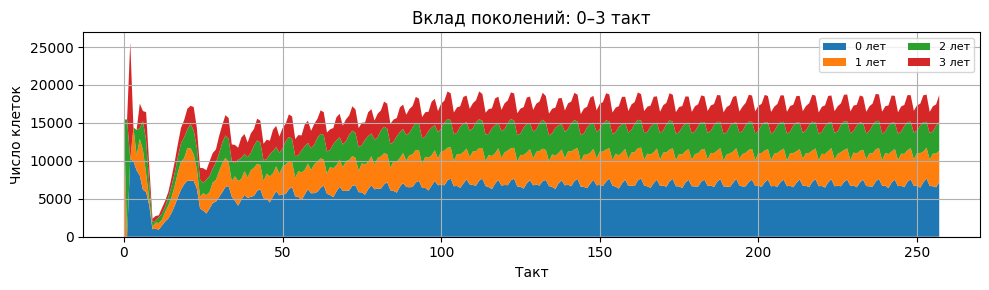

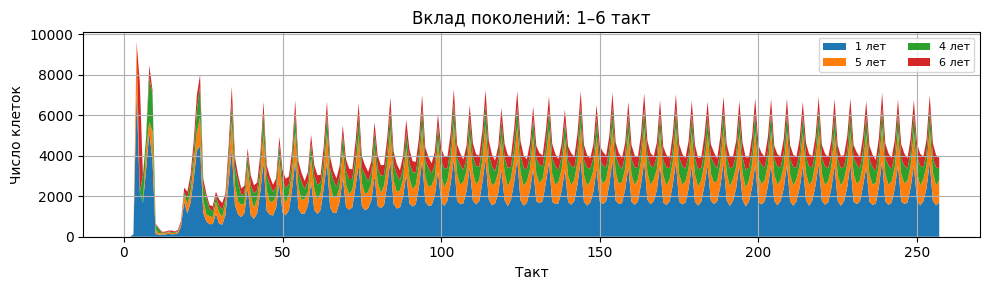

In [17]:
def plot_selected_generations(age_histories, selected_ages):
    import matplotlib.pyplot as plt
    import numpy as np

    age_array = np.array(age_histories).T  # shape: (age, timesteps)

    # Фильтрация по выбранным возрастам
    filtered = age_array[selected_ages, :]

    # Подписи только для выбранных
    labels = [f'{age} лет' for age in selected_ages]

    # Построение графика
    plt.figure(figsize=(10, 3))
    plt.stackplot(range(filtered.shape[1]), filtered, labels=labels)
    plt.xlabel('Такт')
    plt.ylabel('Число клеток')
    plt.title(f'Вклад поколений: {min(selected_ages)}–{max(selected_ages)} такт')
    plt.legend(loc='upper right', ncol=2, fontsize=8)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Пример вызова:

selected_ages=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
age_histories = np.load("age_history.npy")
plot_selected_generations(age_histories, selected_ages=[0,1,2,3])

# Пример вызова:
death_age_histories = np.load("death_age_histories.npy")
plot_selected_generations(death_age_histories, selected_ages=[1,5,4,6])

In [16]:
# Суммируем по всем тактам: получаем сколько умерло в каждом возрасте
total_deaths_by_age = np.sum(age_histories, axis=0)  # shape: (age,)

# Найдём максимальные значения
top_n =15  # сколько самых популярных возрастов смерти вывести
sorted_indices = np.argsort(total_deaths_by_age)[::-1]  # по убыванию

print("Топ возрастов по количеству живых:")
for rank in range(top_n):
    age = sorted_indices[rank]
    deaths = total_deaths_by_age[age]
    print(f"{rank + 1}) {age} такт — {deaths} живые")


# Суммируем по всем тактам: получаем сколько умерло в каждом возрасте
total_deaths_by_age = np.sum(death_age_histories, axis=0)  # shape: (age,)

# Найдём максимальные значения
top_n = 15  # сколько самых популярных возрастов смерти вывести
sorted_indices = np.argsort(total_deaths_by_age)[::-1]  # по убыванию

print("Топ возрастов по количеству смертей:")
for rank in range(top_n):
    age = sorted_indices[rank]
    deaths = total_deaths_by_age[age]
    print(f"{rank + 1}) {age} такт — {deaths} смертей")

Топ возрастов по количеству живых:
1) 0 такт — 1654957 живые
2) 1 такт — 977299 живые
3) 2 такт — 824915 живые
4) 3 такт — 755294 живые
5) 4 такт — 567523 живые
6) 5 такт — 293526 живые
7) 6 такт — 145351 живые
8) 7 такт — 71879 живые
9) 8 такт — 35778 живые
10) 9 такт — 17362 живые
11) 10 такт — 8883 живые
12) 11 такт — 4705 живые
13) 12 такт — 2479 живые
14) 13 такт — 1318 живые
15) 14 такт — 657 живые
Топ возрастов по количеству смертей:
1) 1 такт — 523347 смертей
2) 5 такт — 271386 смертей
3) 4 такт — 183795 смертей
4) 6 такт — 146654 смертей
5) 7 такт — 72818 смертей
6) 3 такт — 65504 смертей
7) 8 такт — 35681 смертей
8) 9 такт — 18213 смертей
9) 10 такт — 8417 смертей
10) 11 такт — 4130 смертей
11) 12 такт — 2209 смертей
12) 13 такт — 1150 смертей
13) 15 такт — 655 смертей
14) 14 такт — 653 смертей
15) 2 такт — 0 смертей
